# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 10     |  |
| :-------------|:-------------|
| Siemen Spek| 6579531 |
| Tom Jongbloed| 6581048 |
| Batu Sönmez| 6175163 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Siemen Spek', 'Tom Jongbloed','Batu Sönmez']

## Opdracht 1: Planning.

| Planning Groep: 10     |Tijdstip / Tijdspanne  |
|---|---|
| pull request gemaakt | 11.30 |
| kalibratie arduinometing | 12.15 |
| testen meetopstelling | 12.45 |
| pauze 1 | 12.45 - 13.45 |
| pauze 2| 16.00 - 16.30 |
| eerste algoritme ideeen| 14.00 |
| iteratie 0 | 14.30 |
| iteratie 1 | 15.00 |
| opdracht af | 17.45 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
from scipy.optimize import curve_fit

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [10]
<img src="kalibratie_opstelling.jpeg" width="400">

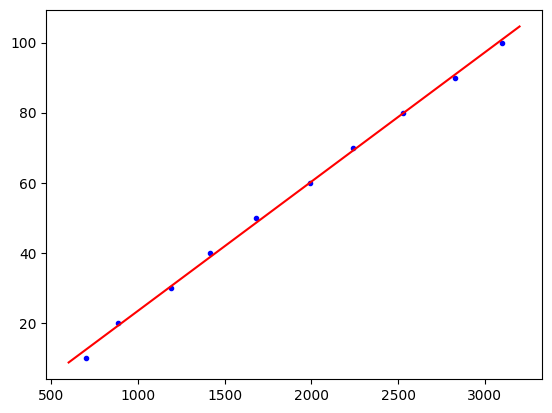

 a = 0.03688
 b = -13.43215


In [3]:
# verwerk hier jullie kalibratiemetingen
kalibratie_bits = np.array([700,886,1189,1413,1680,1992,2242,2530,2825,3100 ])
kalibratie_afstand = np.array([10,20,30,40,50,60,70,80,90,100])


def function(x,a,b):
    return a*x+b

values, covariance = curve_fit(function,kalibratie_bits,kalibratie_afstand)

x_fit = np.linspace(600,3200,300)

plt.figure()
plt.plot(kalibratie_bits,kalibratie_afstand,'b.')
plt.plot(x_fit, function(x_fit,*values),'r-')
plt.show()
print(f' a = {values[0]:.5f}')
print(f' b = {values[1]:.5f}')

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  45.65
1   0  30   0  20  45.02
2  40   0  30   0  40.00
3  30   0  20   0  40.74


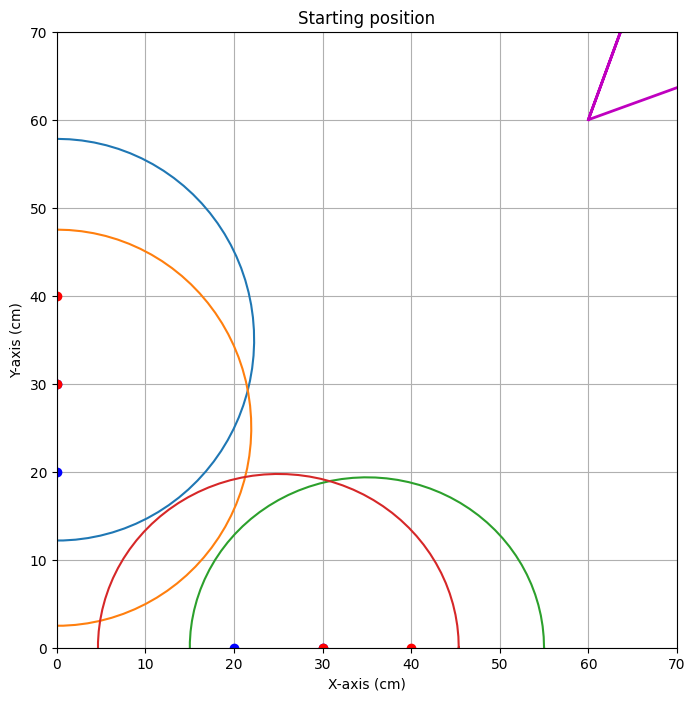


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=99.102


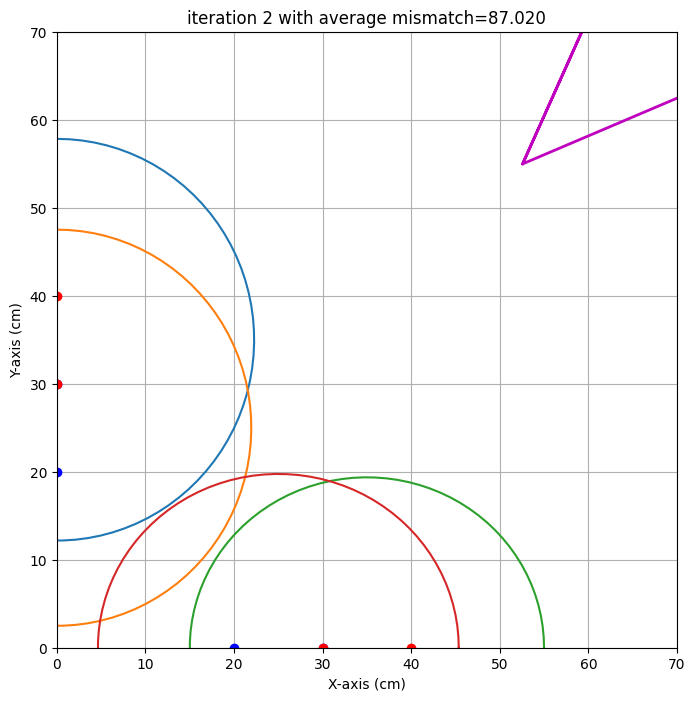

end iteration 2 with average mismatch=87.020


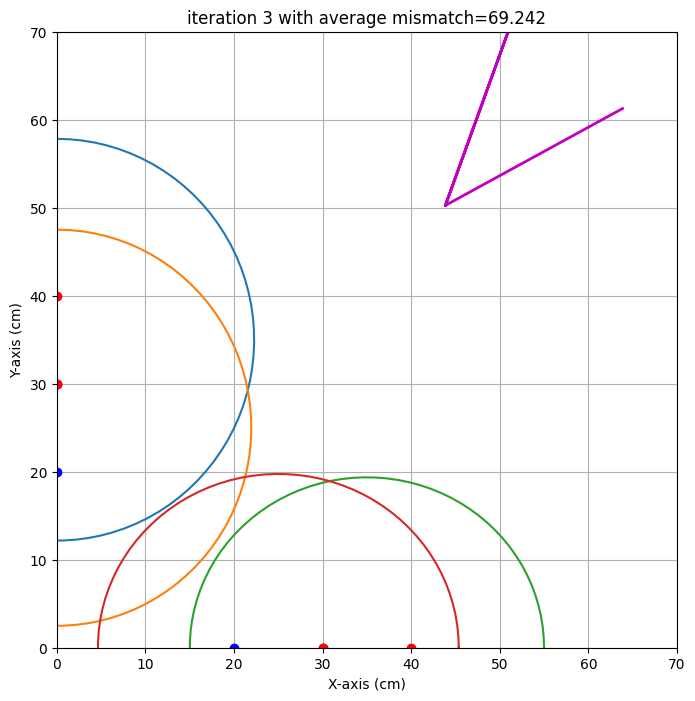

end iteration 3 with average mismatch=69.242


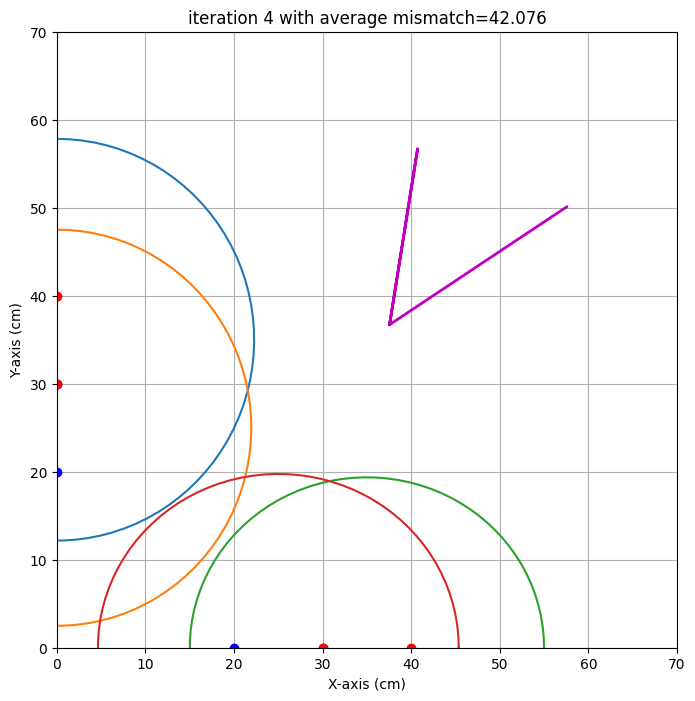

end iteration 4 with average mismatch=42.076


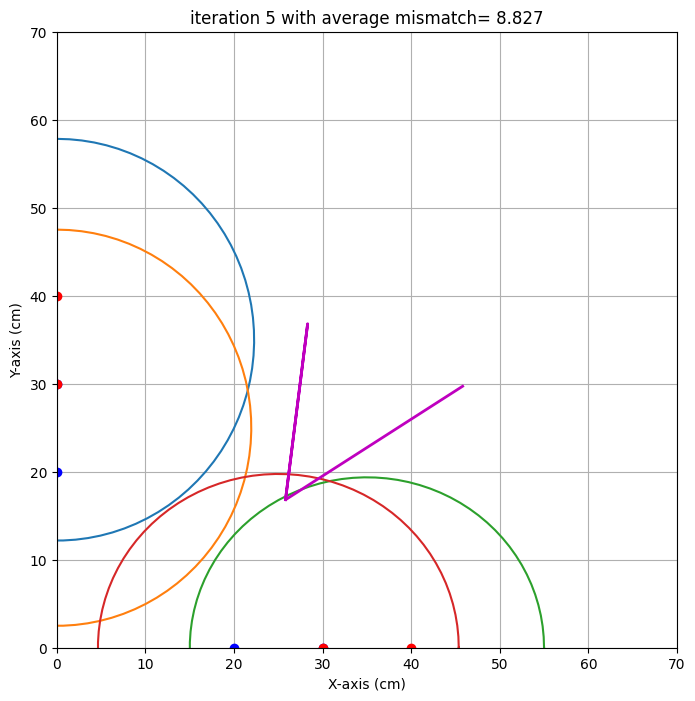

end iteration 5 with average mismatch= 8.827


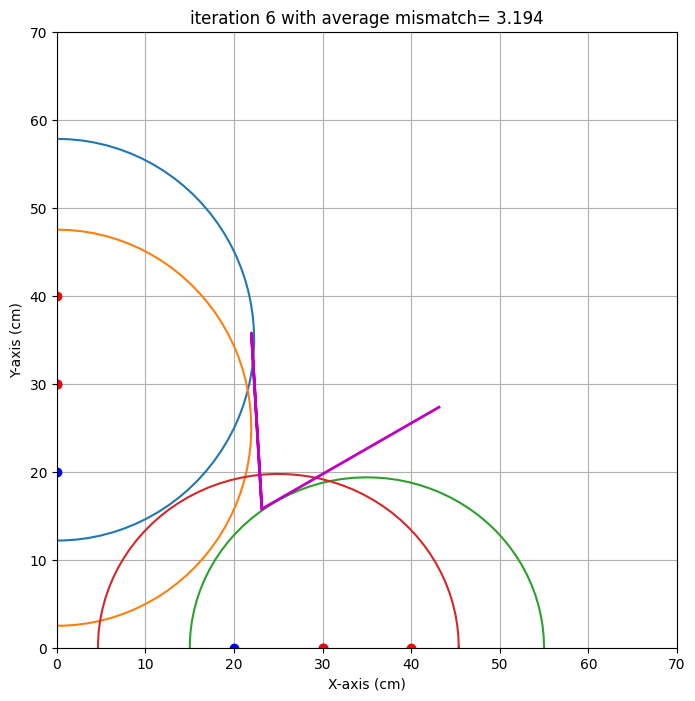

end iteration 6 with average mismatch= 3.194


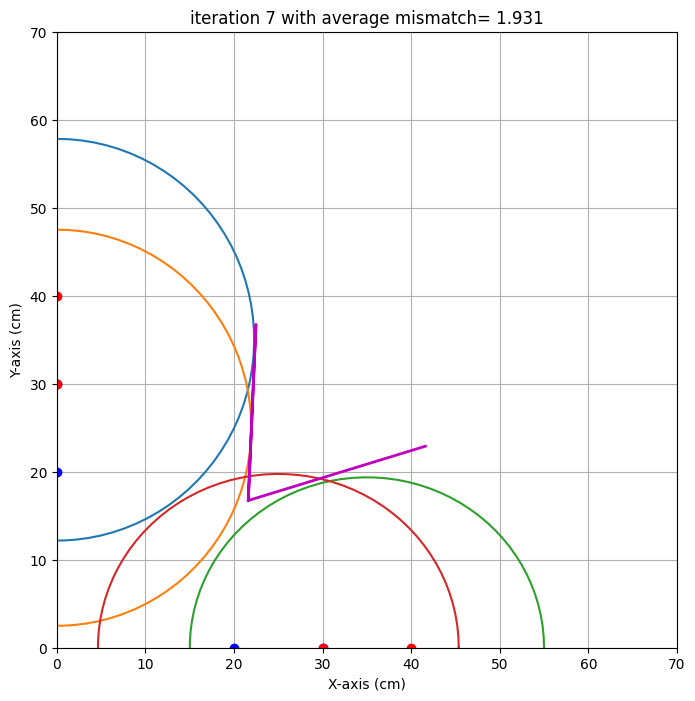

end iteration 7 with average mismatch= 1.931


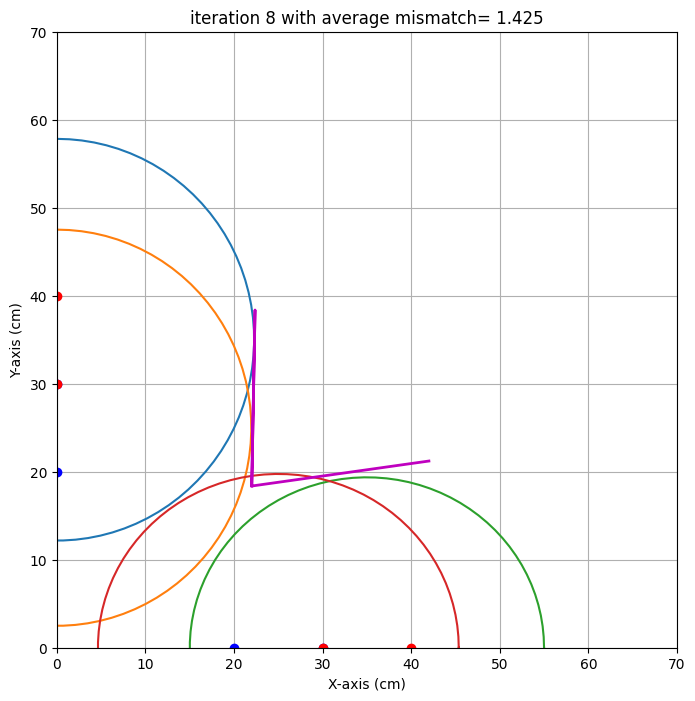

end iteration 8 with average mismatch= 1.425


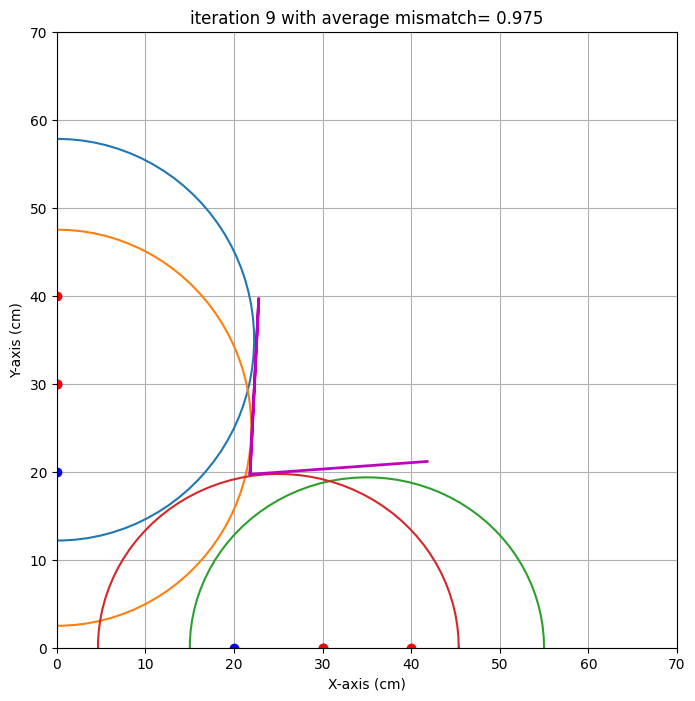

end iteration 9 with average mismatch= 0.975


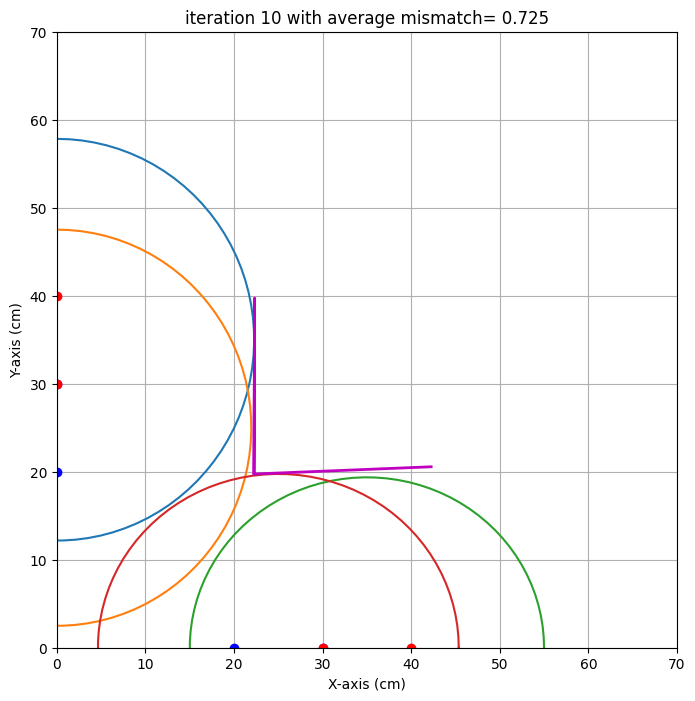

end iteration 10 with average mismatch= 0.725


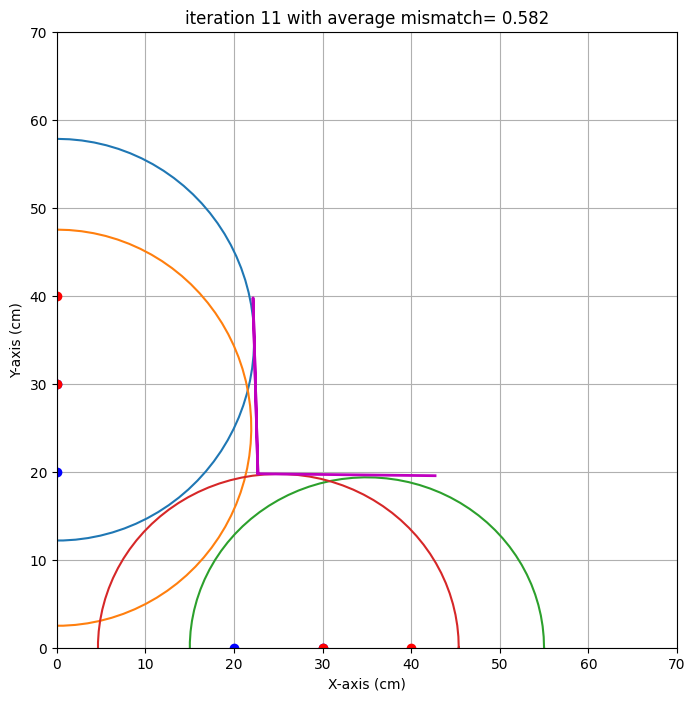

end iteration 11 with average mismatch= 0.582


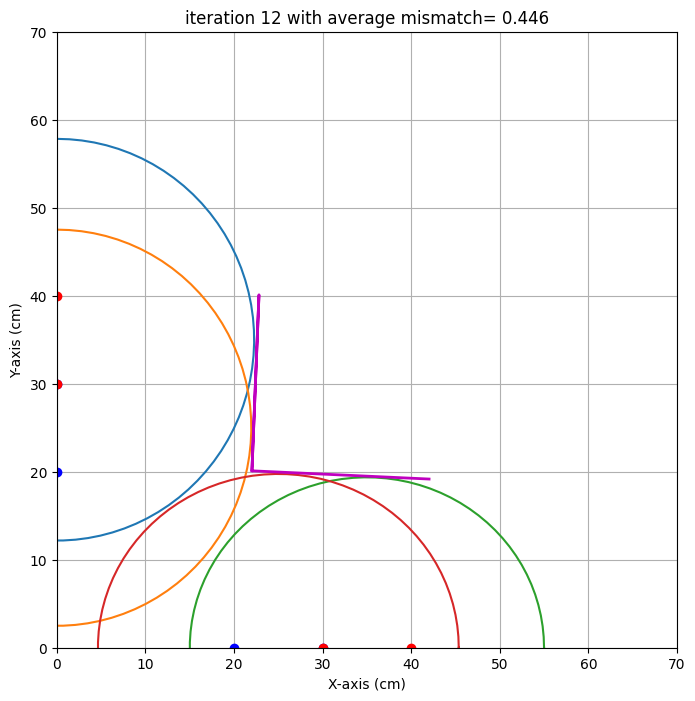

end iteration 12 with average mismatch= 0.446


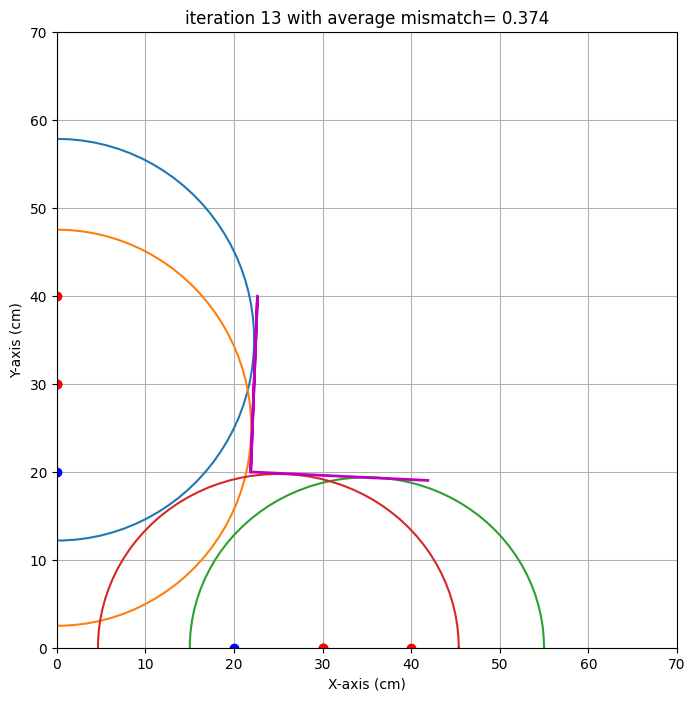

end iteration 13 with average mismatch= 0.374


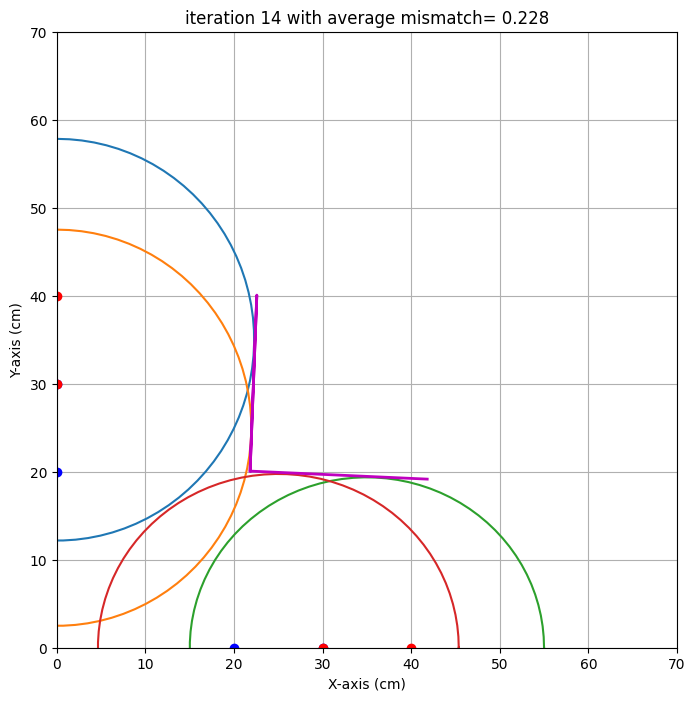

end iteration 14 with average mismatch= 0.228


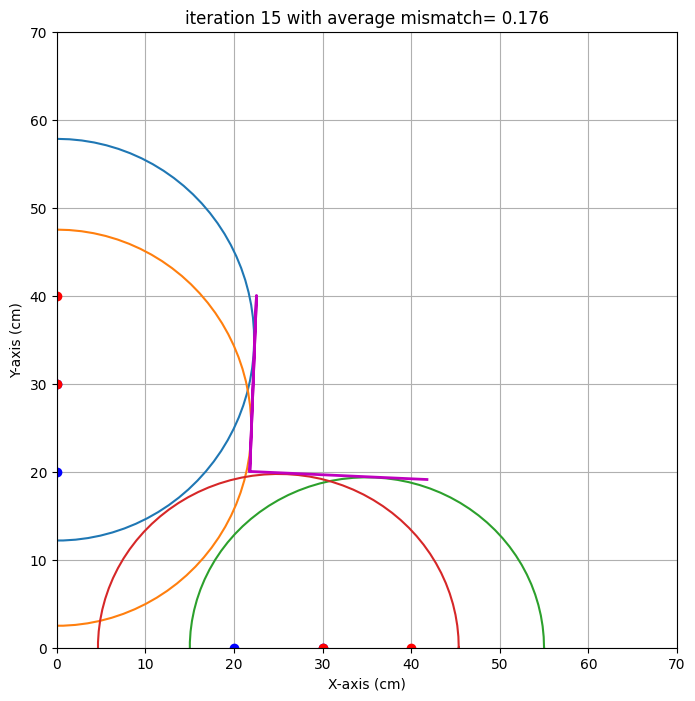

end iteration 15 with average mismatch= 0.176
end iteration 16 with average mismatch= 0.169
end iteration 17 with average mismatch= 0.168
end iteration 18 with average mismatch= 0.167
end iteration 19 with average mismatch= 0.167
end iteration 20 with average mismatch= 0.166
end iteration 21 with average mismatch= 0.166
end iteration 22 with average mismatch= 0.166
end iteration 23 with average mismatch= 0.166
end iteration 24 with average mismatch= 0.166
end iteration 25 with average mismatch= 0.166
end iteration 26 with average mismatch= 0.166
end iteration 27 with average mismatch= 0.166
end iteration 28 with average mismatch= 0.166
end iteration 29 with average mismatch= 0.166
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.166
###############################################################################
end of iteration  30
Best alpha=  -2.62 with uncer

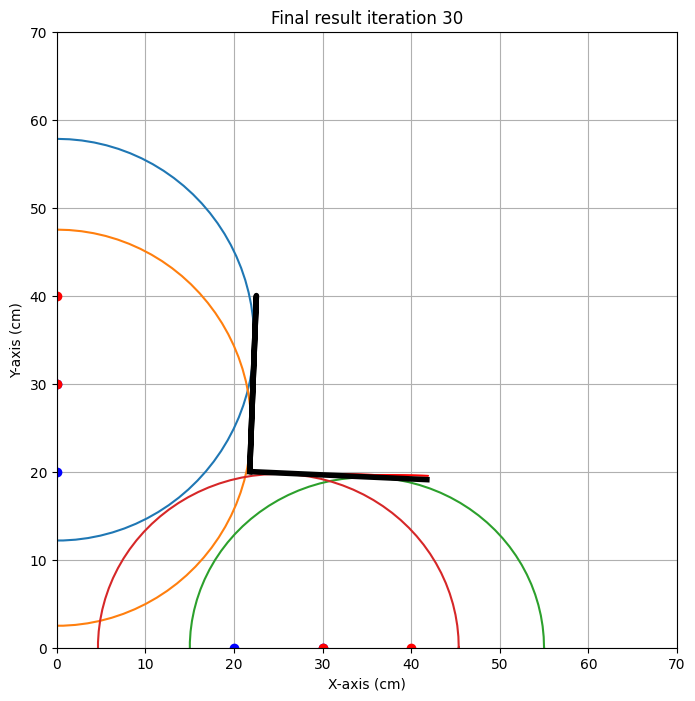

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,45.65],
    [0,30,0,20,45.02],
    [40,0,30,0,40],
    [30,0,20,0,40.74],  
    ])
# [10,0,0,10,]  meting buiten beschouwing gelaten omdat hier de hoek wordt gemeten.
# [10,0,20,0,43.2], 
# 
resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 21.8 cm met een standaardafwijking van 0.1 cm 
y0: 20.0 cm met een standaardafwijking van 0.1 cm 
alpha: -2.6 graden met een standaardafwijking van 1.6 graad 
beta: 2.2 graden met een standaardafwijking van 0.7 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Siemen Spek]
<img src="eerste_algoritme_siemen.jpeg" width="400">

#### algoritme [Batu Sönmez]
<img src="eerste_algoritme_batu.jpeg" width="400">

#### algoritme [Tom Jongbloed]
<img src="eerste_algoritme_tom.jpeg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':40,  
           'y0': 45,
           'alpha' : 25,
           'beta' : 30,
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Siemen Spek' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # [0,30,0,35, ongeldig],
    # [0,45,0,50,ongeldig],
    [60,0,65,0, 93],
    [50,0,60,0, 88],
    #[30,0,35,0,ongeldig],
    [0,45,0,50,93],
    [0,50,0,55,90],
    # siemen
    ]),
       'Tom Jongbloed' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [65,0,55,0,87],
      [55,0,45,0,88.65],
      [0,75,0,65,102.3],
      [0,65,0,55,97],
    # tom
    ]),
       'naam3' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen
    ])
      }

## Opdracht 7: Evaluatie.

Siemen Spek
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  60   0  65   0  93
1  50   0  60   0  88
2   0  45   0  50  93
3   0  50   0  55  90


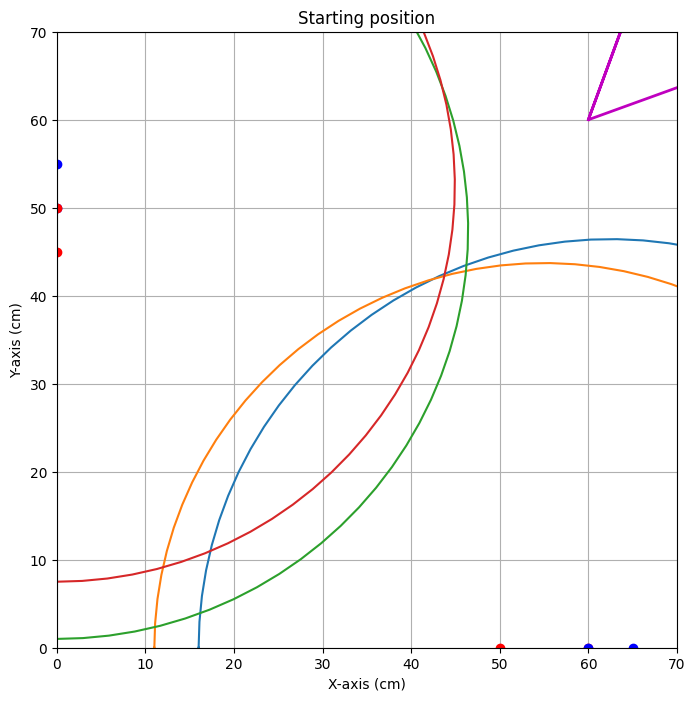


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=36.254


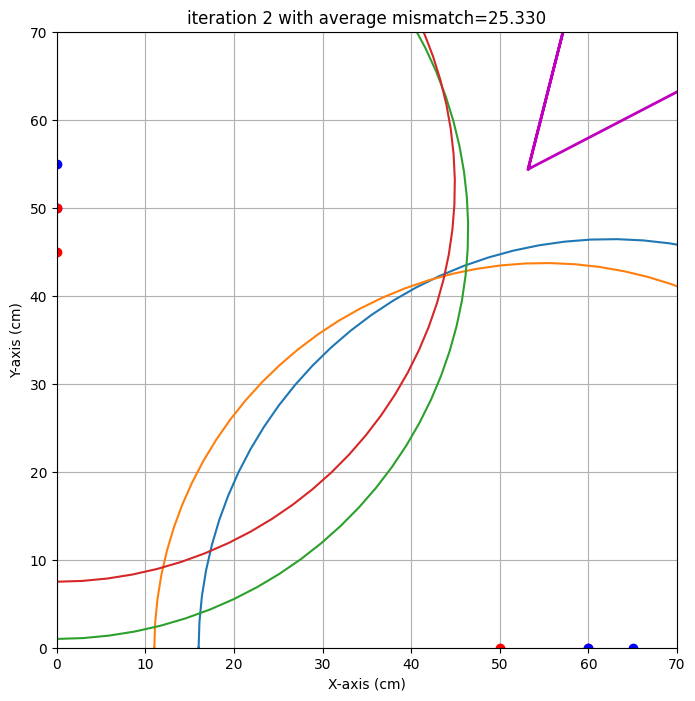

end iteration 2 with average mismatch=25.330


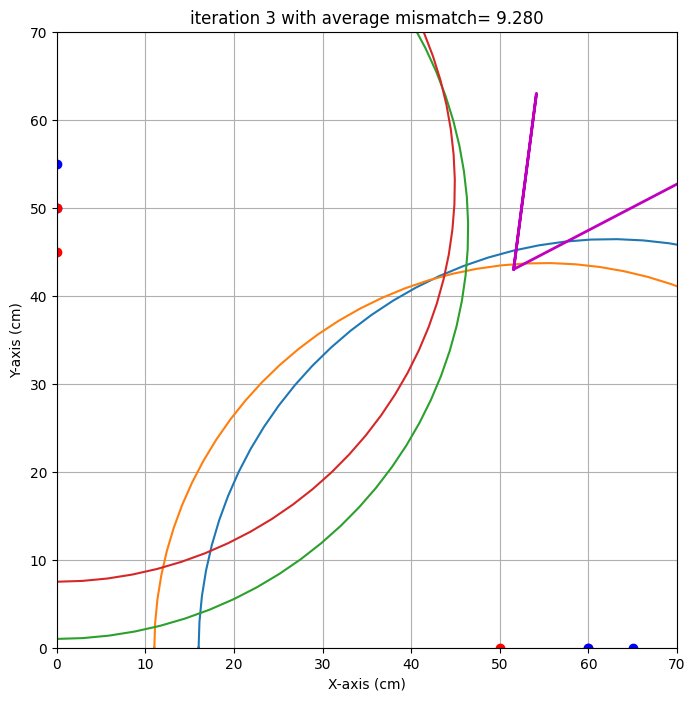

end iteration 3 with average mismatch= 9.280


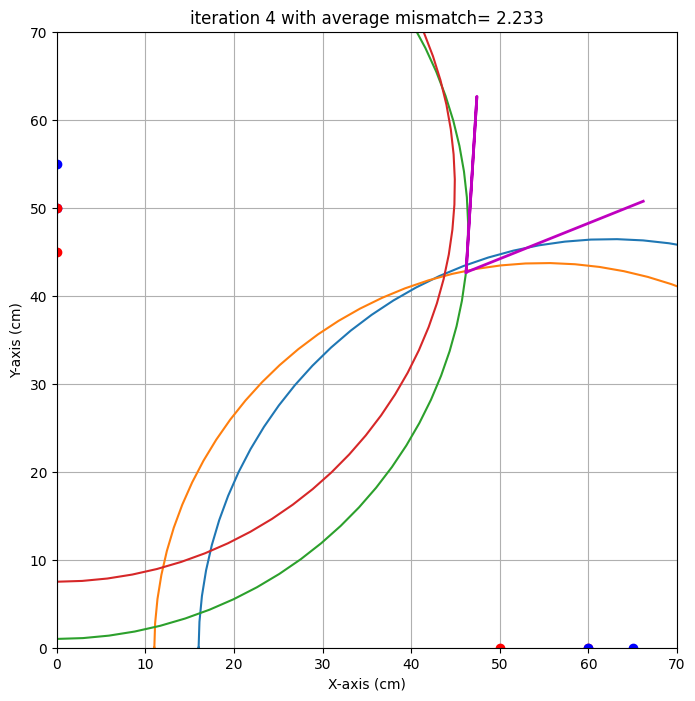

end iteration 4 with average mismatch= 2.233
end iteration 5 with average mismatch= 2.232


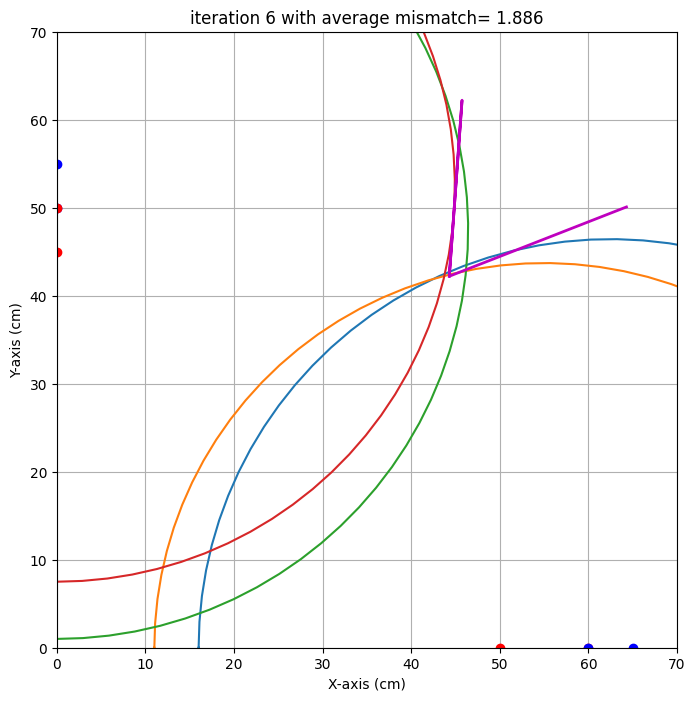

end iteration 6 with average mismatch= 1.886
end iteration 7 with average mismatch= 1.886
end iteration 8 with average mismatch= 1.832
end iteration 9 with average mismatch= 1.740


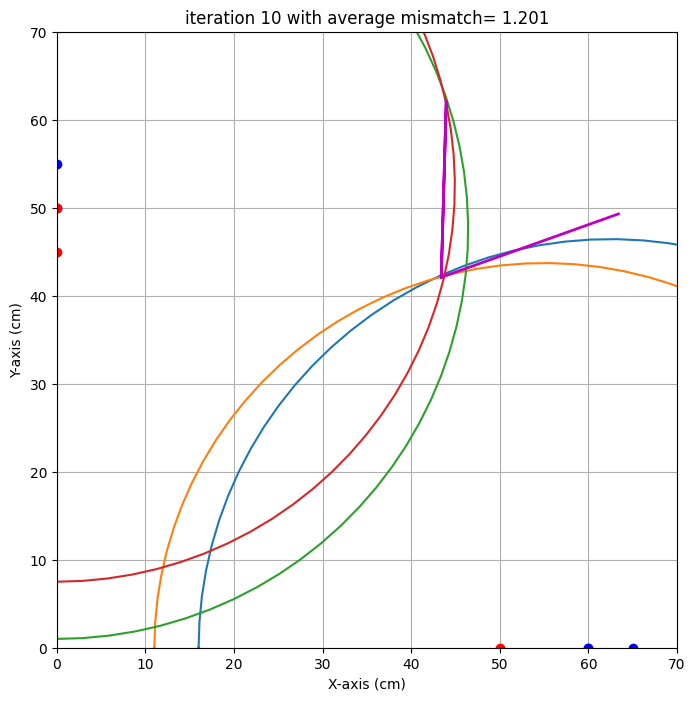

end iteration 10 with average mismatch= 1.201
end iteration 11 with average mismatch= 1.184
end iteration 12 with average mismatch= 1.184
end iteration 13 with average mismatch= 1.184
end iteration 14 with average mismatch= 1.184
end iteration 15 with average mismatch= 1.184
end iteration 16 with average mismatch= 1.184
end iteration 17 with average mismatch= 1.184
end iteration 18 with average mismatch= 1.184
end iteration 19 with average mismatch= 1.184
end iteration 20 with average mismatch= 1.184
end iteration 21 with average mismatch= 1.184
end iteration 22 with average mismatch= 1.155
end iteration 23 with average mismatch= 1.155
end iteration 24 with average mismatch= 1.155
end iteration 25 with average mismatch= 1.155


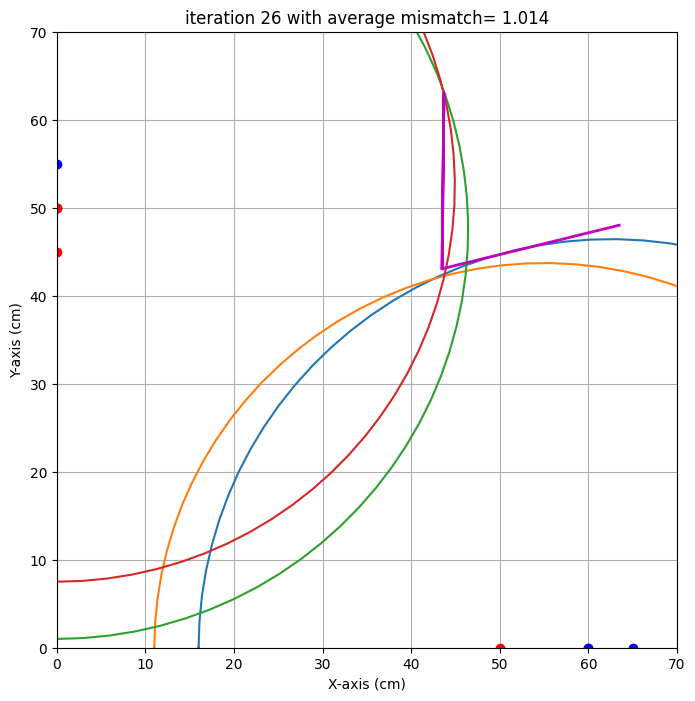

end iteration 26 with average mismatch= 1.014
end iteration 27 with average mismatch= 1.009
end iteration 28 with average mismatch= 0.931
end iteration 29 with average mismatch= 0.898
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.898
###############################################################################
end of iteration  30
Best alpha=  12.26 with uncertainty=   3.98
Best beta =  -2.26 with uncertainty=   6.68
Best x0   =  44.36 with uncertainty=   3.35
Best y0   =  43.58 with uncertainty=   0.96
###############################################################################


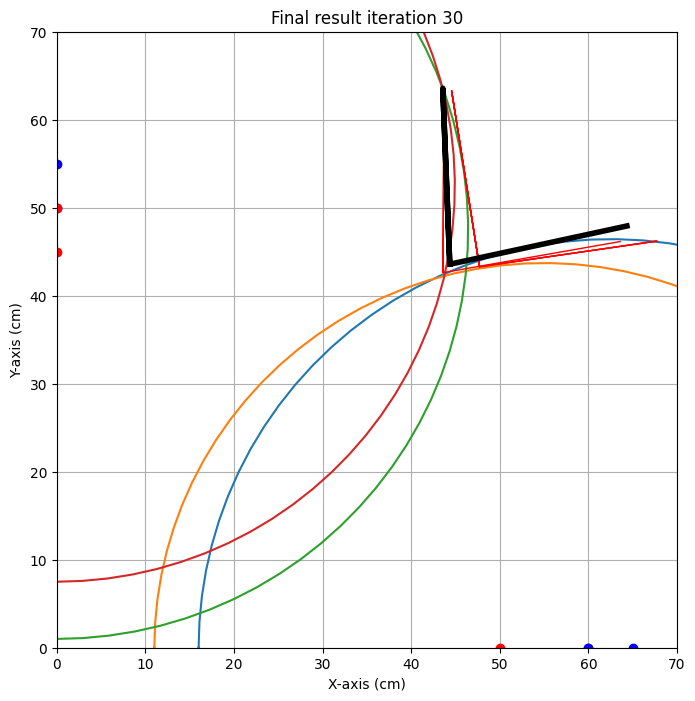

{'alpha': np.float64(12.26371620886555), 'alpha_eps': np.float64(3.978782413728281), 'beta': np.float64(-2.261325135858885), 'beta_eps': np.float64(6.683981088811448), 'x0': np.float64(44.356462537476894), 'x0_eps': np.float64(3.3528685774656353), 'y0': np.float64(43.57888686210148), 'y0_eps': np.float64(0.9583869022556044)}
Tom Jongbloed
Running the imaging algorithm with the following data:
   xs  ys  xr  yr       R
0  65   0  55   0   87.00
1  55   0  45   0   88.65
2   0  75   0  65  102.30
3   0  65   0  55   97.00


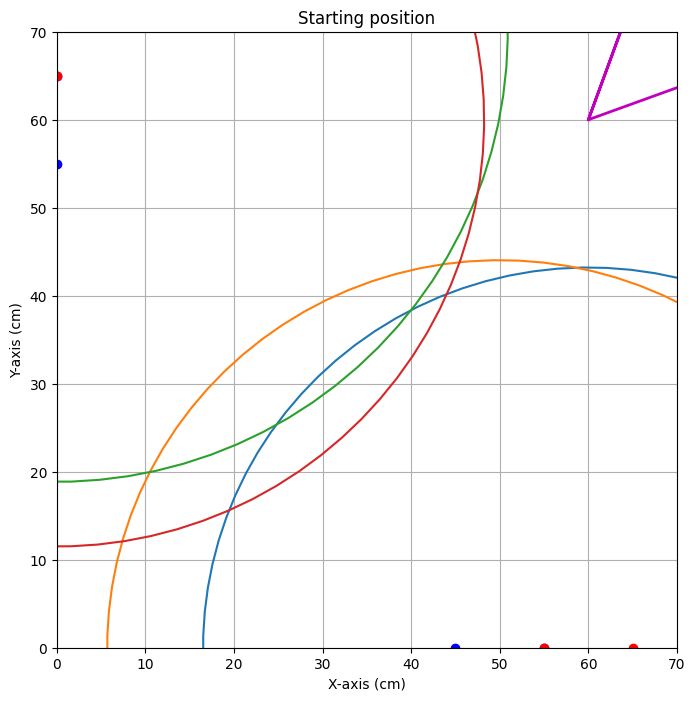


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=32.468


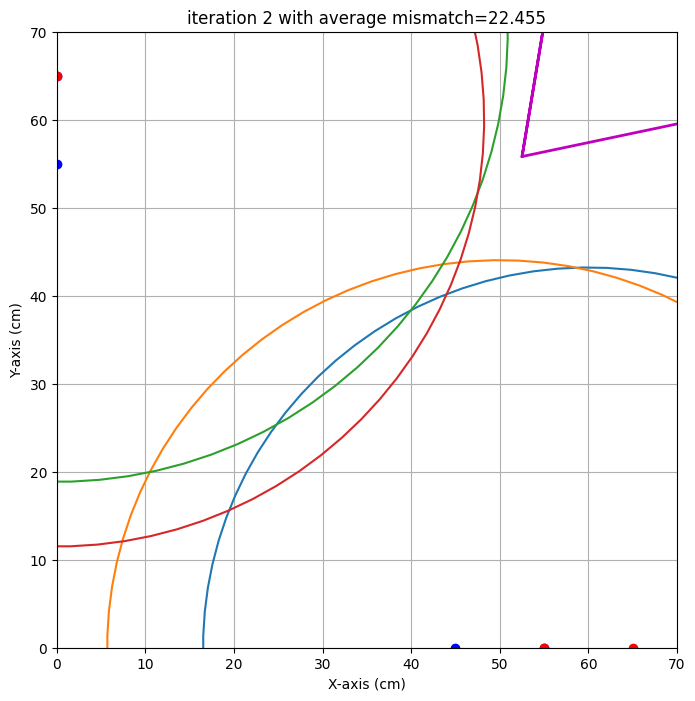

end iteration 2 with average mismatch=22.455


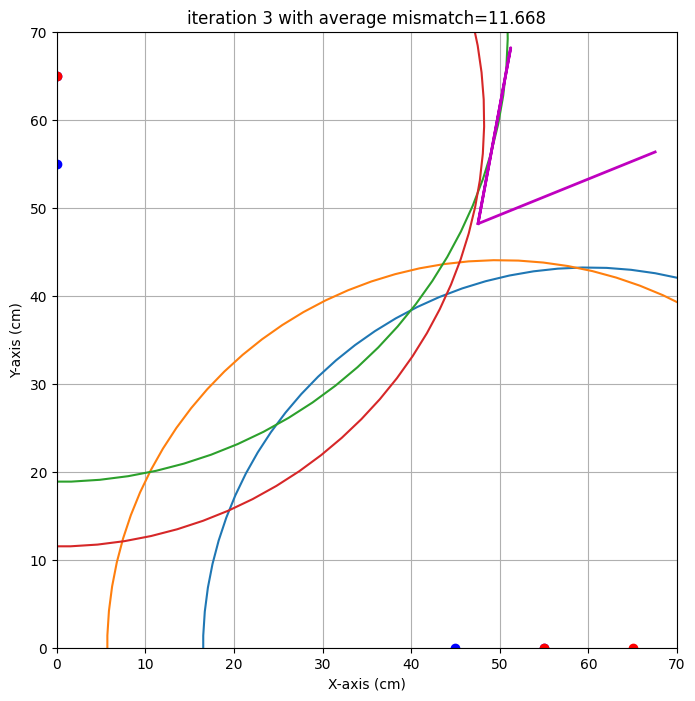

end iteration 3 with average mismatch=11.668


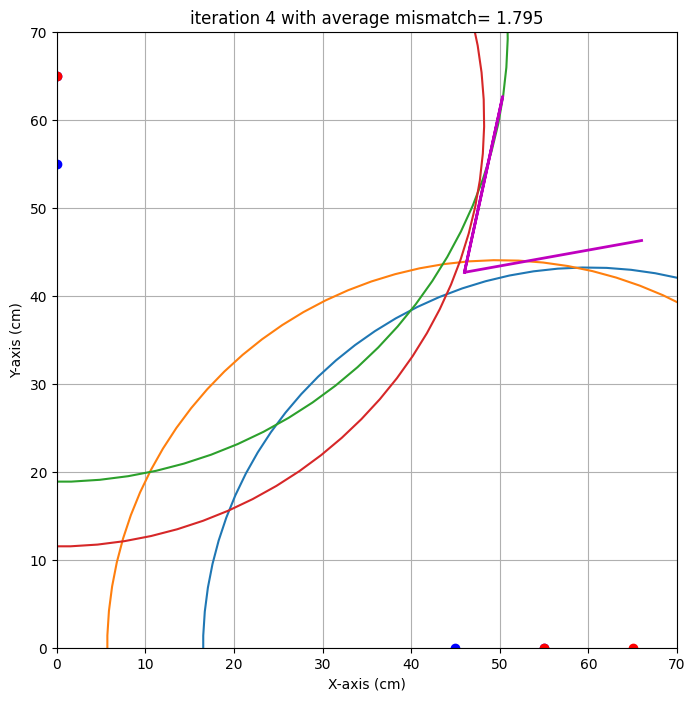

end iteration 4 with average mismatch= 1.795


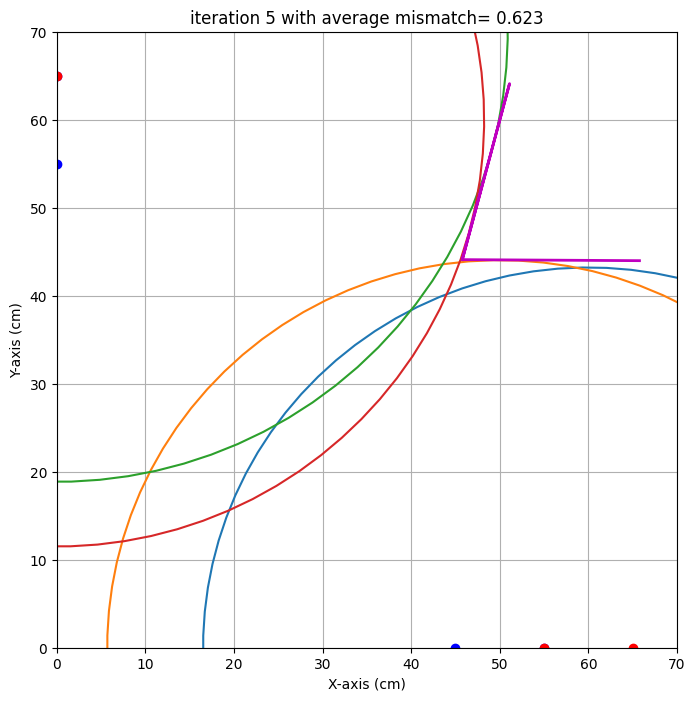

end iteration 5 with average mismatch= 0.623
end iteration 6 with average mismatch= 0.589
end iteration 7 with average mismatch= 0.535


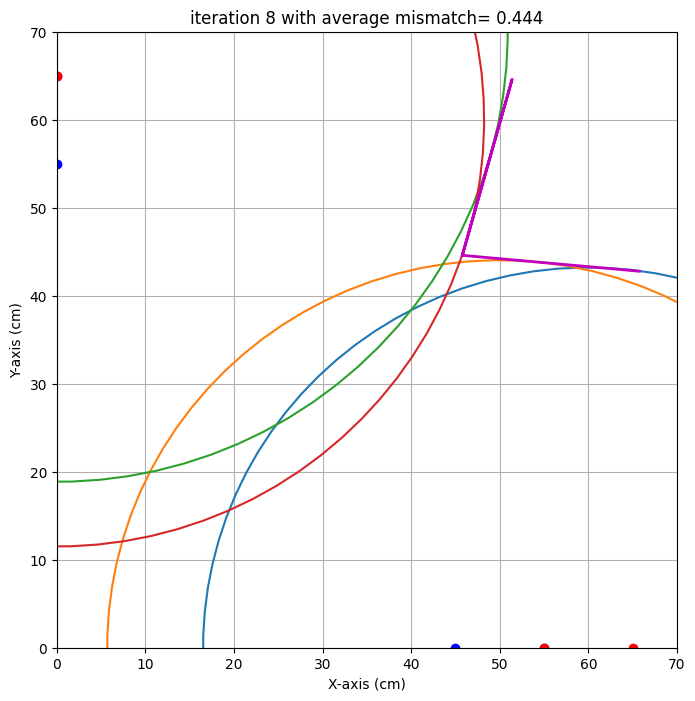

end iteration 8 with average mismatch= 0.444


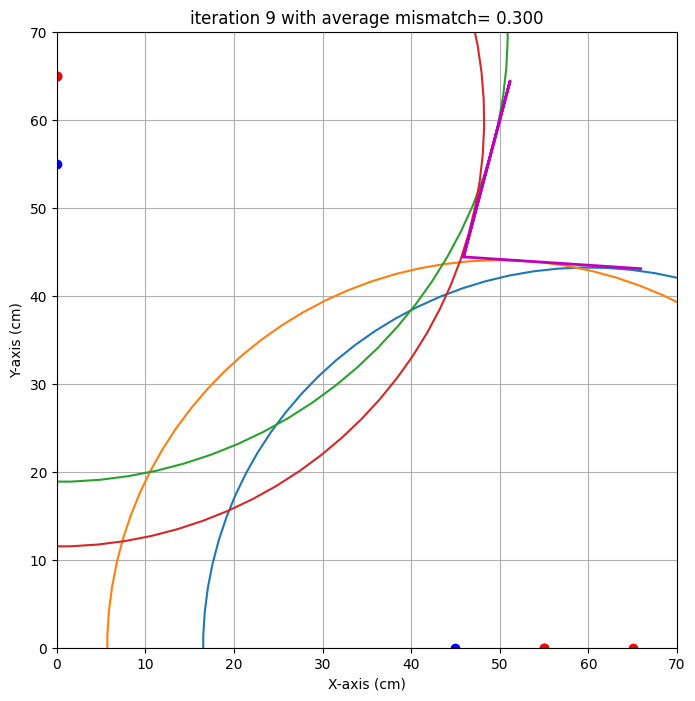

end iteration 9 with average mismatch= 0.300


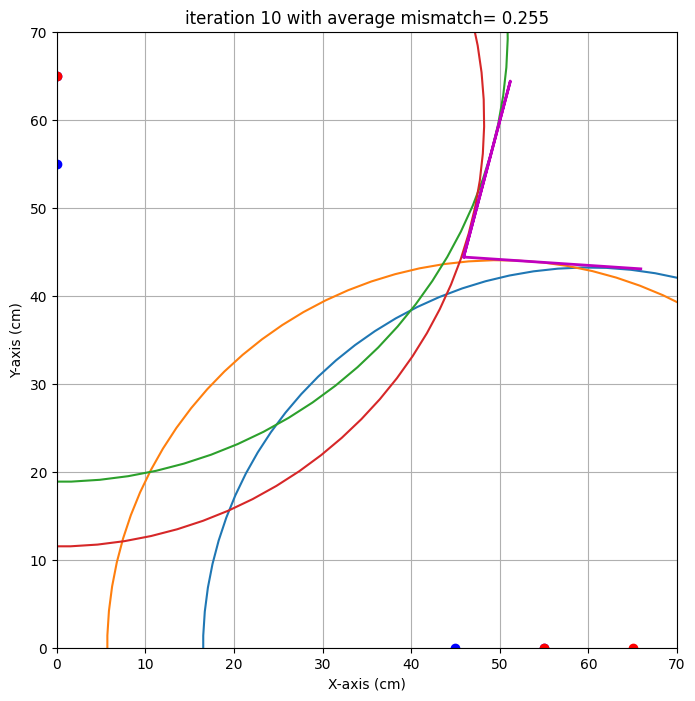

end iteration 10 with average mismatch= 0.255
end iteration 11 with average mismatch= 0.249


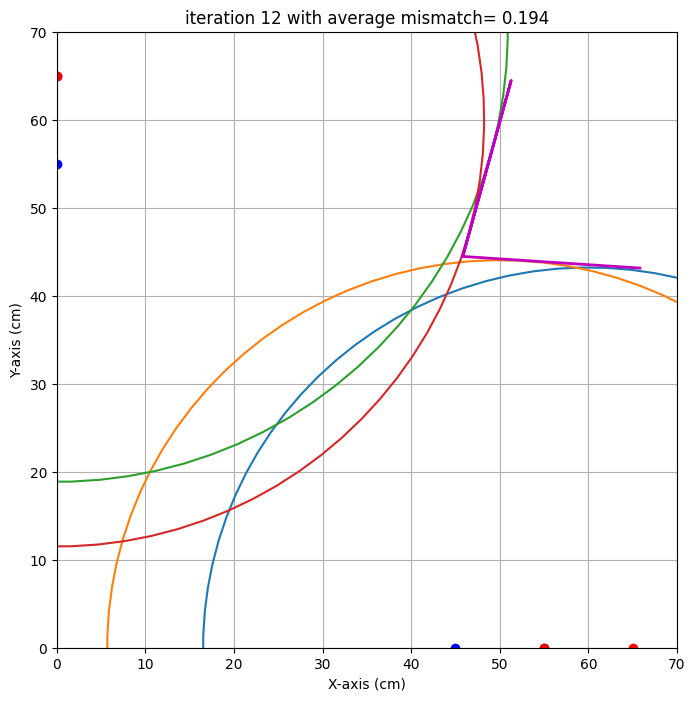

end iteration 12 with average mismatch= 0.194


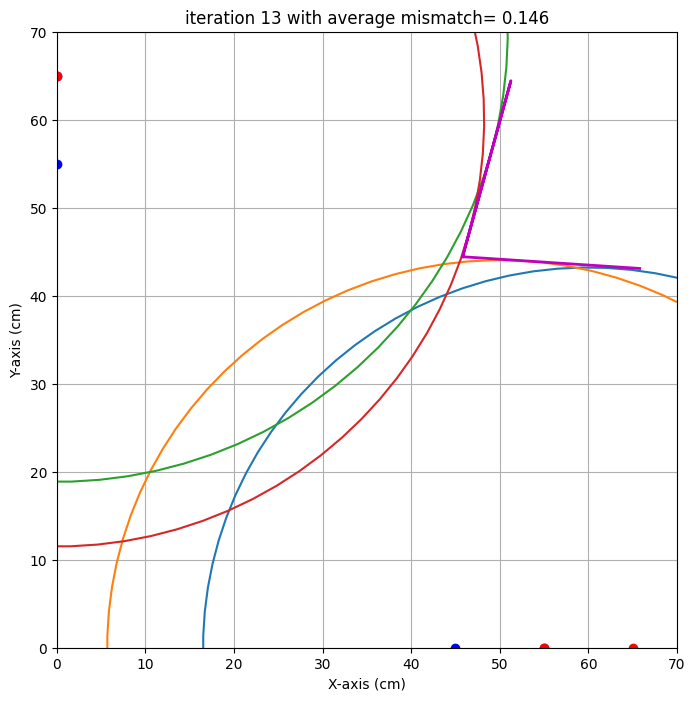

end iteration 13 with average mismatch= 0.146
end iteration 14 with average mismatch= 0.142
end iteration 15 with average mismatch= 0.142
end iteration 16 with average mismatch= 0.141
end iteration 17 with average mismatch= 0.141
end iteration 18 with average mismatch= 0.141
end iteration 19 with average mismatch= 0.141
end iteration 20 with average mismatch= 0.141
end iteration 21 with average mismatch= 0.141
end iteration 22 with average mismatch= 0.141
end iteration 23 with average mismatch= 0.141
end iteration 24 with average mismatch= 0.141
end iteration 25 with average mismatch= 0.141
end iteration 26 with average mismatch= 0.141
end iteration 27 with average mismatch= 0.141
end iteration 28 with average mismatch= 0.141
end iteration 29 with average mismatch= 0.141
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.141
###############################################################

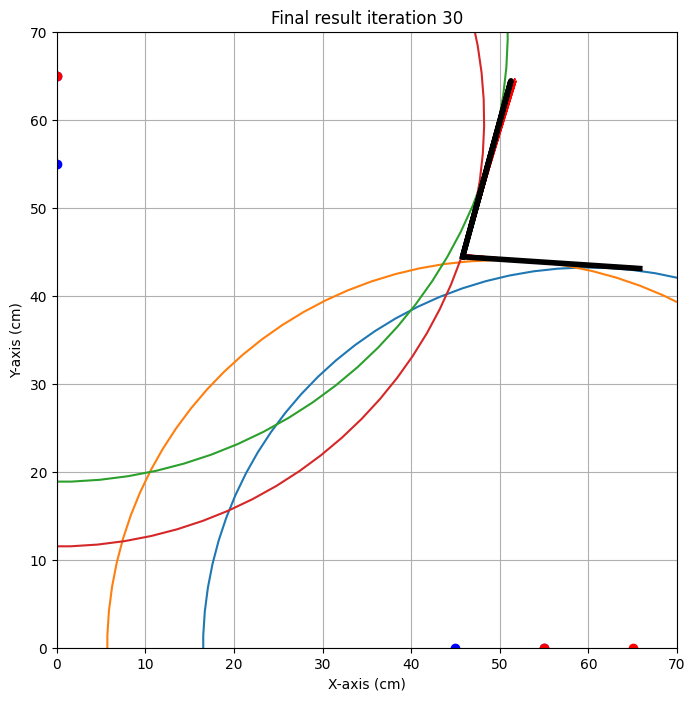

{'alpha': np.float64(-3.8045937217735513), 'alpha_eps': np.float64(1.1169801122046263), 'beta': np.float64(15.260711322444994), 'beta_eps': np.float64(1.652053535749154), 'x0': np.float64(45.80034576301371), 'x0_eps': np.float64(0.21655093610712584), 'y0': np.float64(44.42358810231067), 'y0_eps': np.float64(0.21981063090589714)}
Batu Sönmez


KeyError: 'Batu Sönmez'

In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [ ]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Siemen Spek 
x0 target is : 40.0. Gevonden waarde: 48.7 cm met een standaardafwijking van 4.1 cm 
y0 target is : 45.0. Gevonden waarde: 44.0 cm met een standaardafwijking van 1.7 cm 
alpha target is : 25.0. Gevonden waarde: 5.5 graden met een standaardafwijking van 10.2 graad 
beta target is : 30.0. Gevonden waarde: -13.8 graden met een standaardafwijking van 12.1 graad 

Tom Jongbloed 
x0 target is : 40.0. Gevonden waarde: 45.8 cm met een standaardafwijking van 0.2 cm 
y0 target is : 45.0. Gevonden waarde: 44.7 cm met een standaardafwijking van 0.6 cm 
alpha target is : 25.0. Gevonden waarde: -5.4 graden met een standaardafwijking van 3.7 graad 
beta target is : 30.0. Gevonden waarde: 15.9 graden met een standaardafwijking van 1.2 graad 



KeyError: 'Batu Sönmez'

## Opdracht 8: Iteratie1+.14.45.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](algoritme_einde.jpeg)


In [ ]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  70   0  60  68.18
1   0  75   0  60  70.00
2   0  65   0  55  66.40
3   0  65   0  50  65.12
4  55   0  45   0  68.10
5  55   0  40   0  69.66


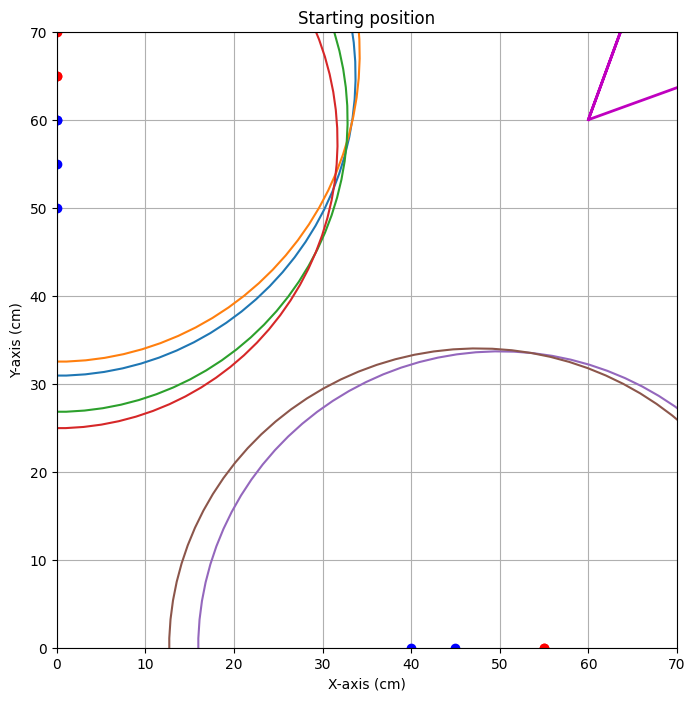


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=57.378


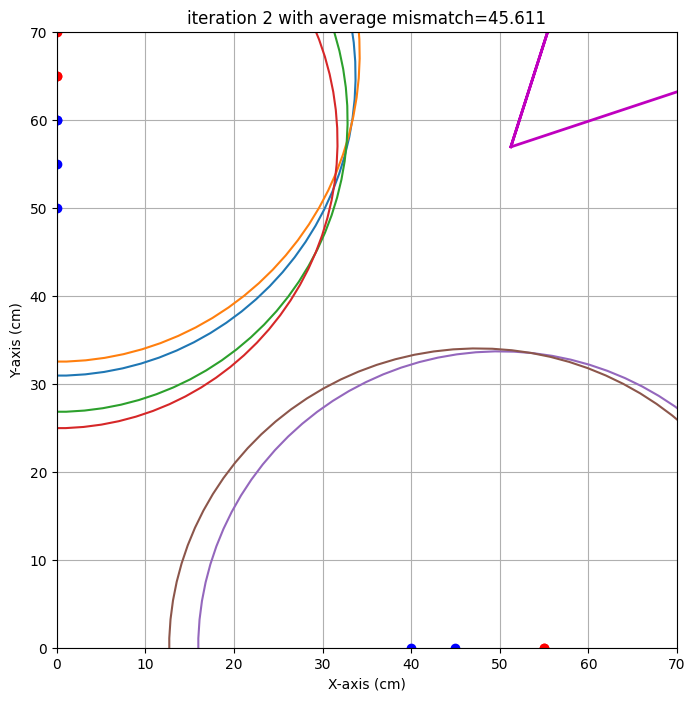

end iteration 2 with average mismatch=45.611


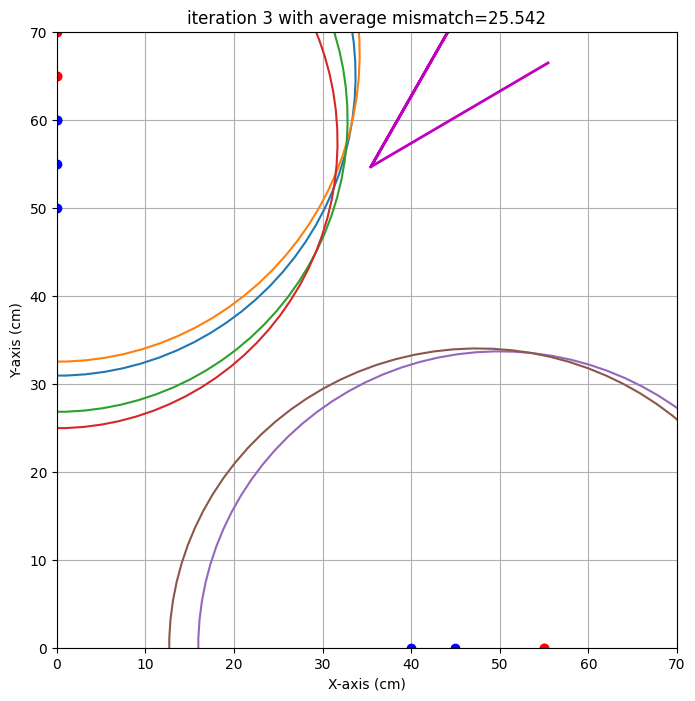

end iteration 3 with average mismatch=25.542


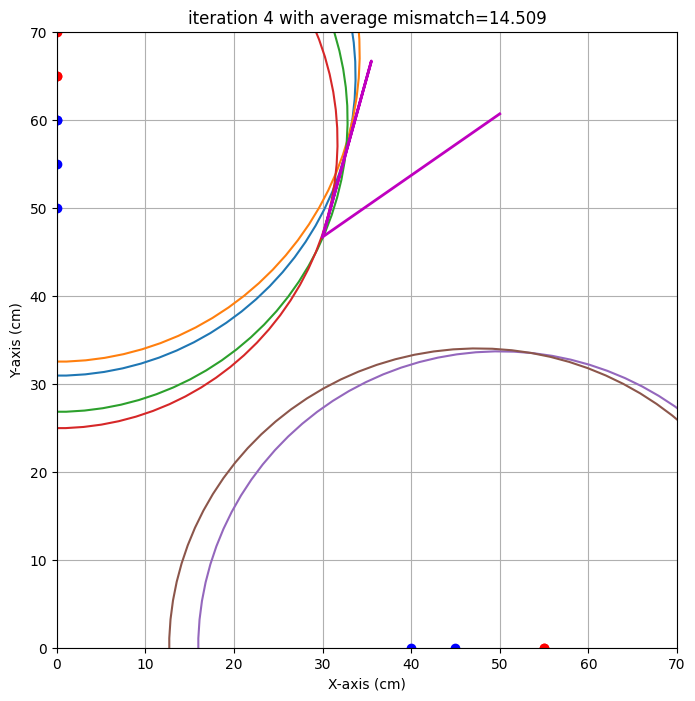

end iteration 4 with average mismatch=14.509


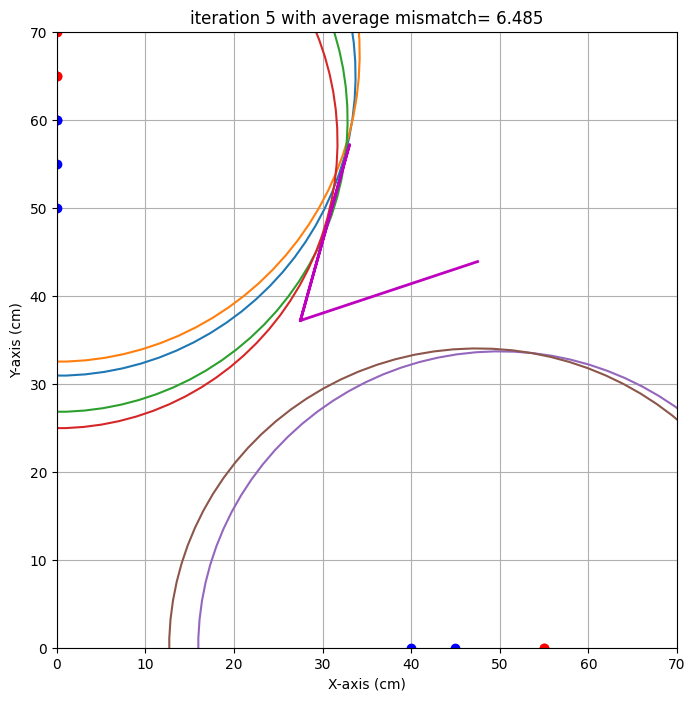

end iteration 5 with average mismatch= 6.485


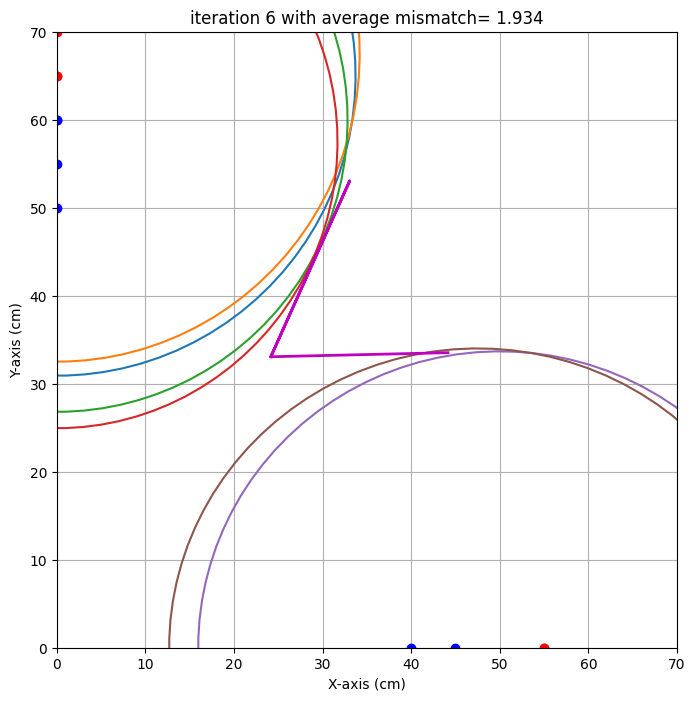

end iteration 6 with average mismatch= 1.934
end iteration 7 with average mismatch= 1.927
end iteration 8 with average mismatch= 1.882
end iteration 9 with average mismatch= 1.729
end iteration 10 with average mismatch= 1.706
end iteration 11 with average mismatch= 1.706
end iteration 12 with average mismatch= 1.706
end iteration 13 with average mismatch= 1.706
end iteration 14 with average mismatch= 1.706
end iteration 15 with average mismatch= 1.706
end iteration 16 with average mismatch= 1.706
end iteration 17 with average mismatch= 1.706
end iteration 18 with average mismatch= 1.706
end iteration 19 with average mismatch= 1.706
end iteration 20 with average mismatch= 1.706
end iteration 21 with average mismatch= 1.706
end iteration 22 with average mismatch= 1.706
end iteration 23 with average mismatch= 1.706
end iteration 24 with average mismatch= 1.706
end iteration 25 with average mismatch= 1.706
end iteration 26 with average mismatch= 1.706
end iteration 27 with average mismatch

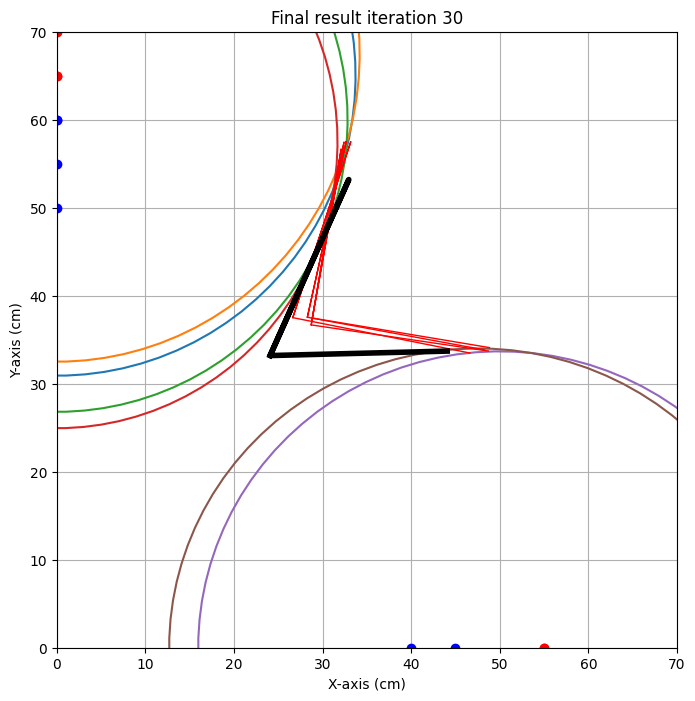

{'alpha': np.float64(1.4503804267616835), 'alpha_eps': np.float64(12.818589456733244), 'beta': np.float64(23.956684942490334), 'beta_eps': np.float64(14.352803322266634), 'x0': np.float64(24.069571652303356), 'x0_eps': np.float64(4.766871111975192), 'y0': np.float64(33.200467630858824), 'y0_eps': np.float64(4.353131477494571)}
locatie 1 
x0 target is : 27.0. Gevonden waarde: 24.1 cm met een standaardafwijking van 4.8 cm 
y0 target is : 35.0. Gevonden waarde: 33.2 cm met een standaardafwijking van 4.4 cm 
alpha target is : -26.0. Gevonden waarde: 1.5 graden met een standaardafwijking van 12.8 graad 
beta target is : 20.0. Gevonden waarde: 24.0 graden met een standaardafwijking van 14.4 graad 



In [ ]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 27,
                    'y0': 35,
                    'alpha' : -26,
                    'beta' : 20,                  
           'locatie 2':{'x0':34,
                    'y0':34,
                    'alpha' :34, 
                    'beta' :34, 
            }}}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,70,0,60,68.18],
    [0,75,0,60,70],
    [0,65,0,55,66.4],
    [0,65,0,50,65.12],
    # [60,0,50,0,79],
    # [65,0,50,0,ongeldig],
    [55,0,45,0,68.1],
    [55,0,40,0,69.66],
    # zelf aanvullen
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  55   0  45  53.0
1   0  50   0  40  48.5
2   0  50   0  35  51.0
3  45   0  35   0  45.0
4  50   0  35   0  44.9
5  40   0  30   0  47.0
6  40   0  25   0  49.2


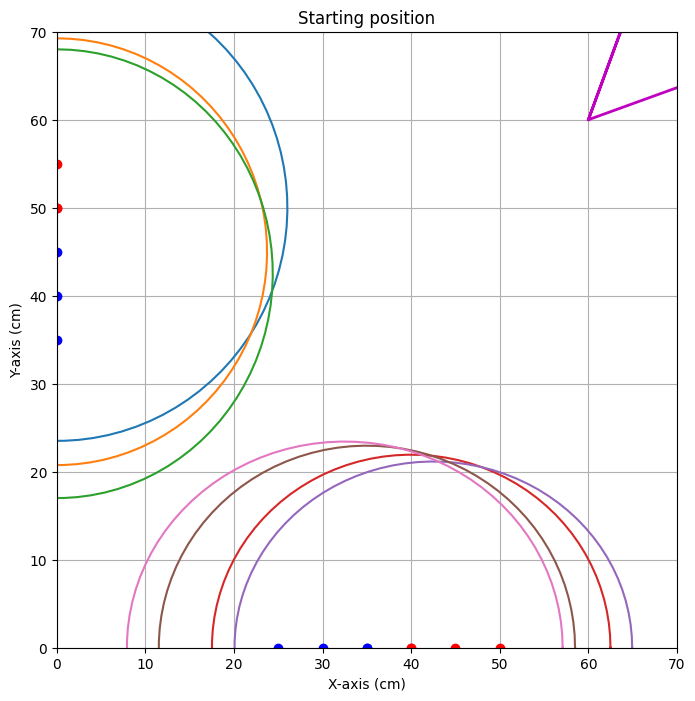


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=85.182


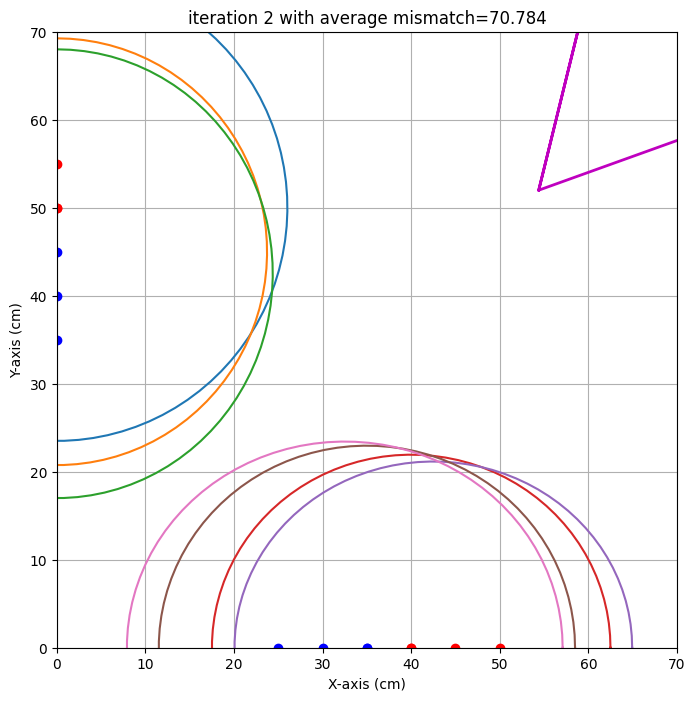

end iteration 2 with average mismatch=70.784


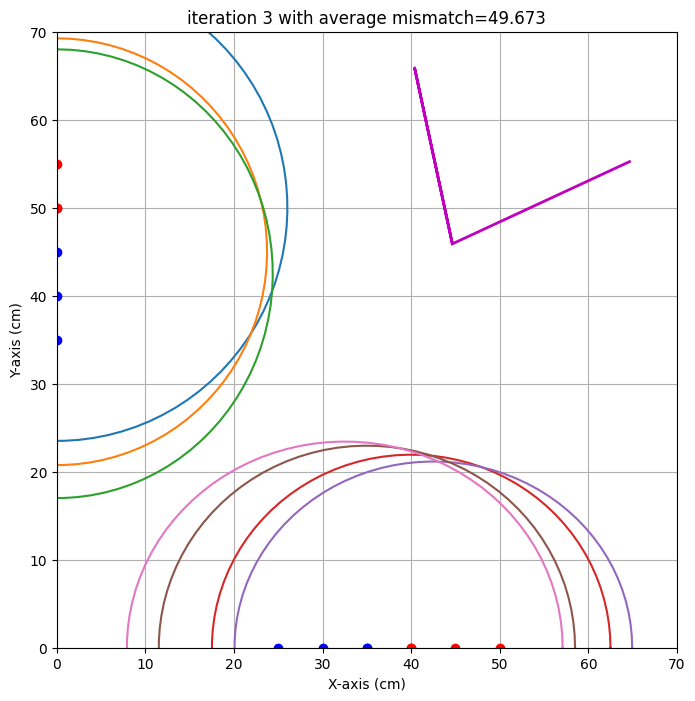

end iteration 3 with average mismatch=49.673


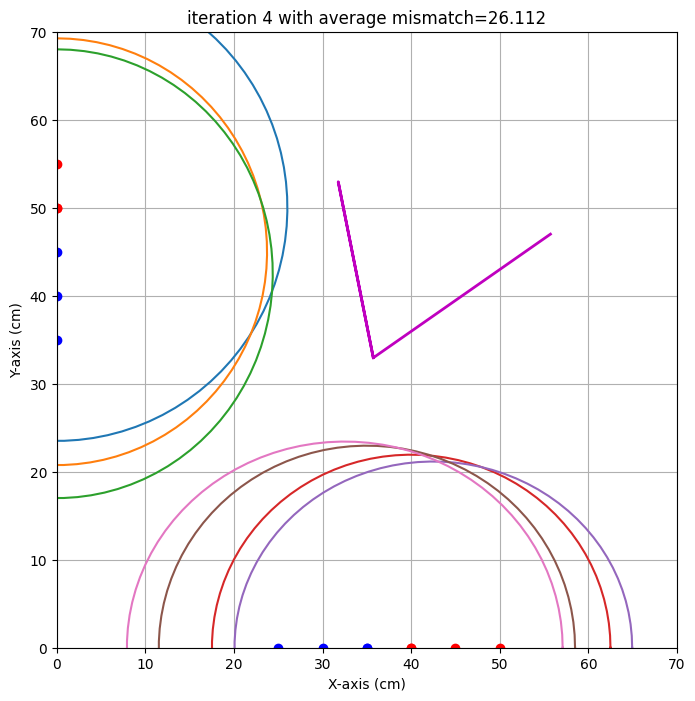

end iteration 4 with average mismatch=26.112


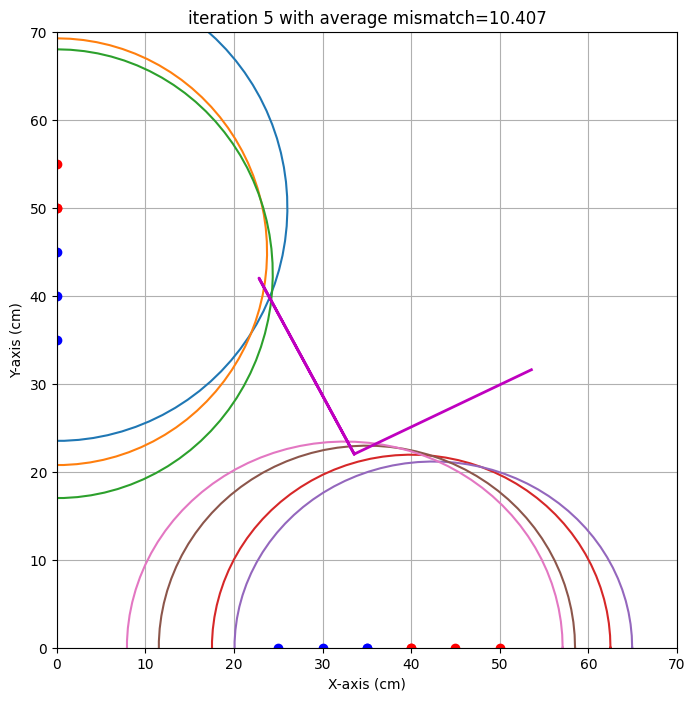

end iteration 5 with average mismatch=10.407


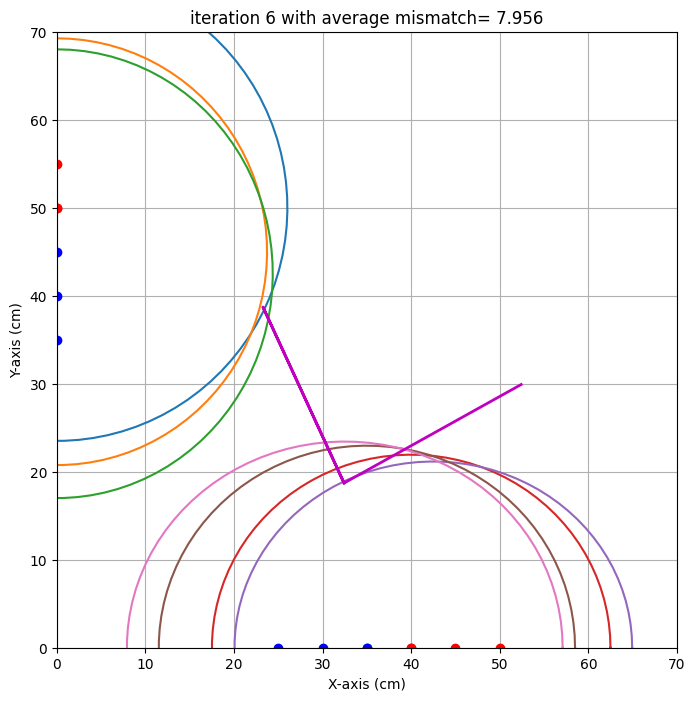

end iteration 6 with average mismatch= 7.956
end iteration 7 with average mismatch= 7.731


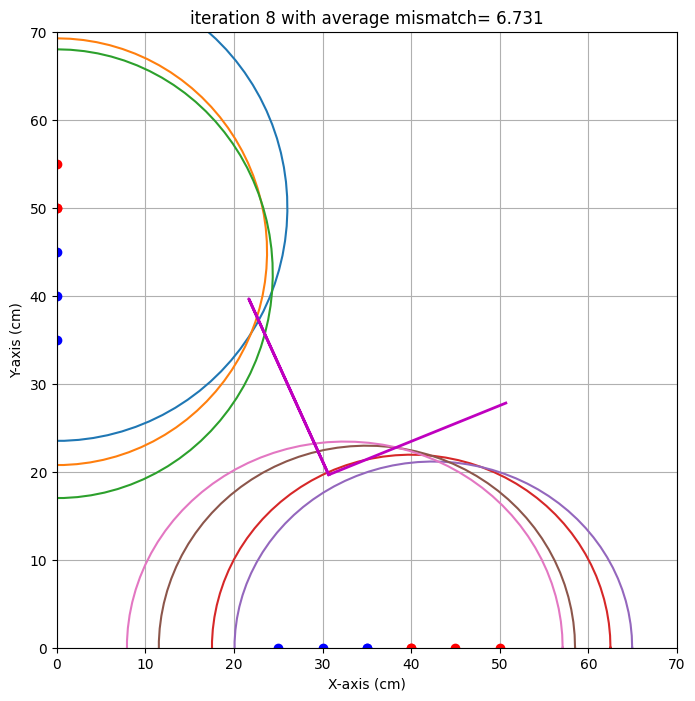

end iteration 8 with average mismatch= 6.731


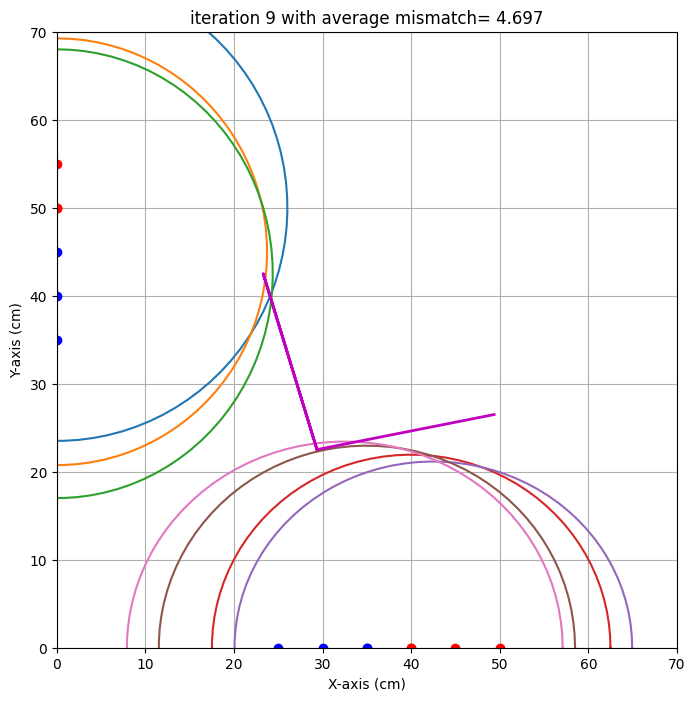

end iteration 9 with average mismatch= 4.697


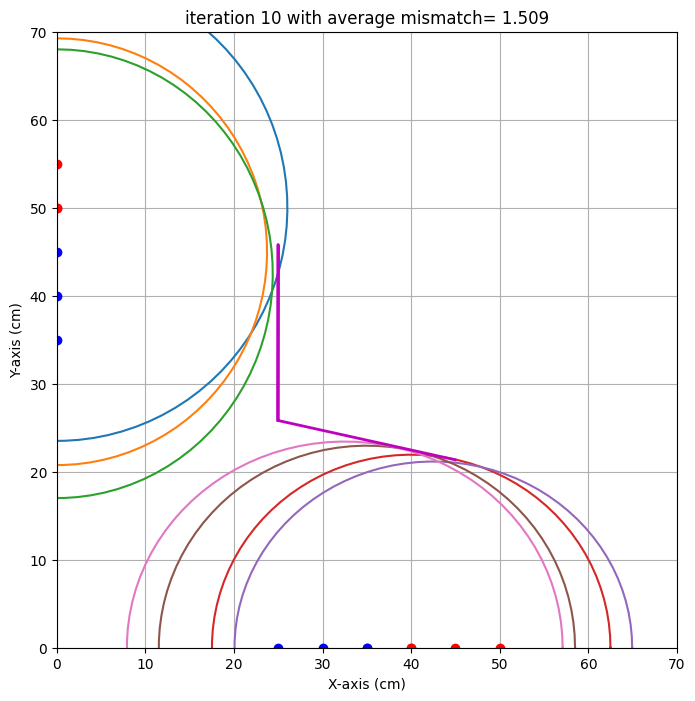

end iteration 10 with average mismatch= 1.509
end iteration 11 with average mismatch= 1.456
end iteration 12 with average mismatch= 1.413
end iteration 13 with average mismatch= 1.409
end iteration 14 with average mismatch= 1.409
end iteration 15 with average mismatch= 1.409
end iteration 16 with average mismatch= 1.409
end iteration 17 with average mismatch= 1.409
end iteration 18 with average mismatch= 1.409
end iteration 19 with average mismatch= 1.409
end iteration 20 with average mismatch= 1.409
end iteration 21 with average mismatch= 1.409
end iteration 22 with average mismatch= 1.409
end iteration 23 with average mismatch= 1.409
end iteration 24 with average mismatch= 1.409
end iteration 25 with average mismatch= 1.409
end iteration 26 with average mismatch= 1.396
end iteration 27 with average mismatch= 1.395
end iteration 28 with average mismatch= 1.392
end iteration 29 with average mismatch= 1.392
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

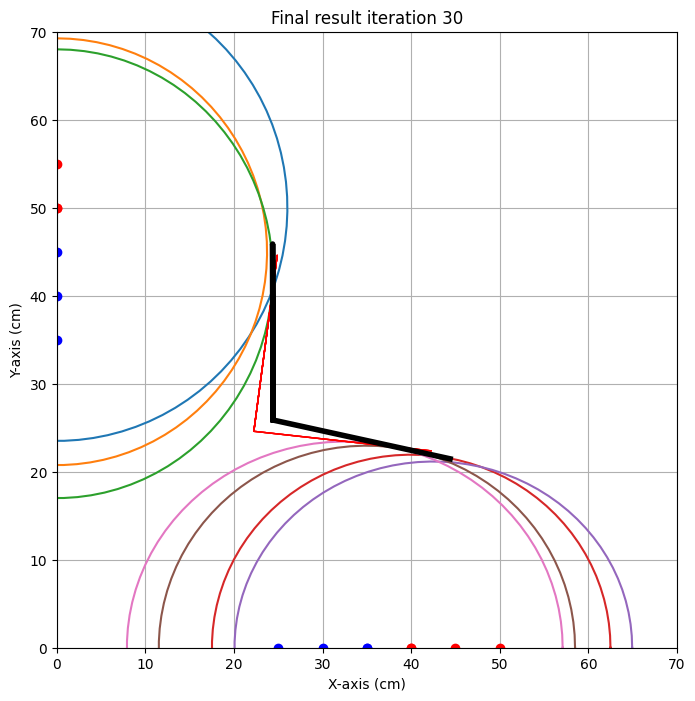

{'alpha': np.float64(-12.434594891554115), 'alpha_eps': np.float64(6.102690570789664), 'beta': np.float64(-0.11187592455745934), 'beta_eps': np.float64(7.631596772197858), 'x0': np.float64(24.393542791978103), 'x0_eps': np.float64(2.1586326528192856), 'y0': np.float64(25.874797880680127), 'y0_eps': np.float64(1.2813068913799697)}
test locatie 
x0 target is : 25.6. Gevonden waarde: 24.4 cm met een standaardafwijking van 2.2 cm 
y0 target is : 26.2. Gevonden waarde: 25.9 cm met een standaardafwijking van 1.3 cm 
alpha target is : -15.0. Gevonden waarde: -12.4 graden met een standaardafwijking van 6.1 graad 
beta target is : -2.0. Gevonden waarde: -0.1 graden met een standaardafwijking van 7.6 graad 



In [ ]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 25.6 ,
                    'y0': 26.2 ,
                    'alpha' : -15 ,
                    'beta' :  -2
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    # [0,70,0,60,ongeldig],
                    # [0,55,0,45,56],
                    # [0,60,0,45,ongeldig],
                    # [0,50,0,40,51.2],
                    # [0,50,0,35,54],
                    # [60,0,50,0,ongeldig],
                    # [45,0,35,0,47],
                    # [50,0,35,0,47.5],
                    # [40,0,30,0,50],
                    # [40,0,25,0,52],
                    # tweede metingen:
                    # [0,70,0,60,ongeldig],
                    [0,55,0,45,53],
                    [0,50,0,40,48.5],
                    [0,50,0,35,51],
                    # [60,0,50,0,ongeldig],
                    [45,0,35,0,45],
                    [50,0,35,0,44.9],
                    [40,0,30,0,47],
                    [40,0,25,0,49.2],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

De blauwe ellips valt deze buiten onze waarden, omdat wij hierbij precies de rand meten.

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](eerste_algoritme_siemen.jpeg "Title")
evaluaties:
werkte niet goed, geeft heel andere hoeken dan gemeten. Vooral verschillende afstanden tussen bron en ontvanger toevoegen.

Figuur: ![Alt](iteratie_1.jpeg "Title")
evaluaties: komt in de buurt, nog steeds hoeken niet goed bepaald, dus nog meer metingen met kleine variatie in afstand tussen bron en ontvanger.

Figuur: ![Alt](algoritme_einde.jpeg "Title")

onze uiteindelijke meetopstelling:
Figuur: ![Alt](uiteindelijke_meetopstelling.jpeg "Title")

In [ ]:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 25.6 ,
                    'y0': 26.2 ,
                    'alpha' : -15 ,
                    'beta' :  -2
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    # [0,70,0,60,ongeldig],
                    # [0,55,0,45,56],
                    # [0,60,0,45,ongeldig],
                    # [0,50,0,40,51.2],
                    # [0,50,0,35,54],
                    # [60,0,50,0,ongeldig],
                    # [45,0,35,0,47],
                    # [50,0,35,0,47.5],
                    # [40,0,30,0,50],
                    # [40,0,25,0,52],
                    # tweede metingen:
                    # [0,70,0,60,ongeldig],
                    [0,55,0,45,53],
                    [0,50,0,40,48.5],
                    [0,50,0,35,51],
                    # [60,0,50,0,ongeldig],
                    [45,0,35,0,45],
                    [50,0,35,0,44.9],
                    [40,0,30,0,47],
                    [40,0,25,0,49.2],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))